In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [7]:
class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    result: str

In [9]:
def first_node(state: AgentState) -> AgentState:
    state['result'] = f"{state['name']}, welcome to the system! "

    return state


def second_node(state: AgentState) -> AgentState:
    state['result'] = state['result'] + f"You are {state['age']} years old! "

    return state


def third_node(state: AgentState) -> AgentState:
    state['result'] = state['result'] + f"You have skills in {",".join(state['skills'][:-1])}, and {state['skills'][-1]}"

    return state

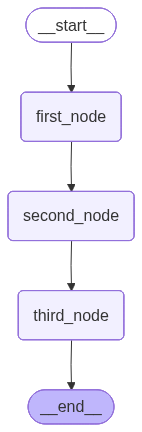

In [10]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_node("third_node", third_node)

graph.add_edge("first_node", "second_node")
graph.add_edge("second_node", "third_node")

graph.set_entry_point("first_node")
graph.set_finish_point("third_node")

app = graph.compile()

app

In [12]:
result = app.invoke({"name": "Linda", "age": 31, "skills": ["Python", "Machine Learning", "LangGraph"]})

result["result"]

'Linda, welcome to the system! You are 31 years old! You have skills in Python,Machine Learning, and LangGraph'